# Week 10 - Notes: Modeling Chaotic Systems

## Duffing Oscillator

The Duffing oscillator is a non-linear second-order differential equation that describes the motion of a damped and driven oscillator with a non-linear restoring force. It is given by:

$$\frac{d^2x}{dt^2} + \delta \frac{dx}{dt} + \alpha x + \beta x^3 = \gamma \cos(\omega t)$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.integrate import solve_ivp
plt.style.use('seaborn-v0_8-colorblind')

In [41]:
def duffing(t, y, delta, alpha, beta, gamma, omega):
    x, v = y
    dxdt = v
    dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
    return [dxdt, dvdt]

# Parameters
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.2
omega = 1.2

# Time span and initial conditions
cycles = 40
tfinal = 2 * np.pi * cycles / omega
t_span = (0, tfinal)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
y0 = [1.0, 0.0]

# Solve the differential equations
sol = solve_ivp(duffing, t_span, y0, args=(delta, alpha, beta, gamma, omega), t_eval=t_eval)
x = sol.y[0]
v = sol.y[1]
t = sol.t

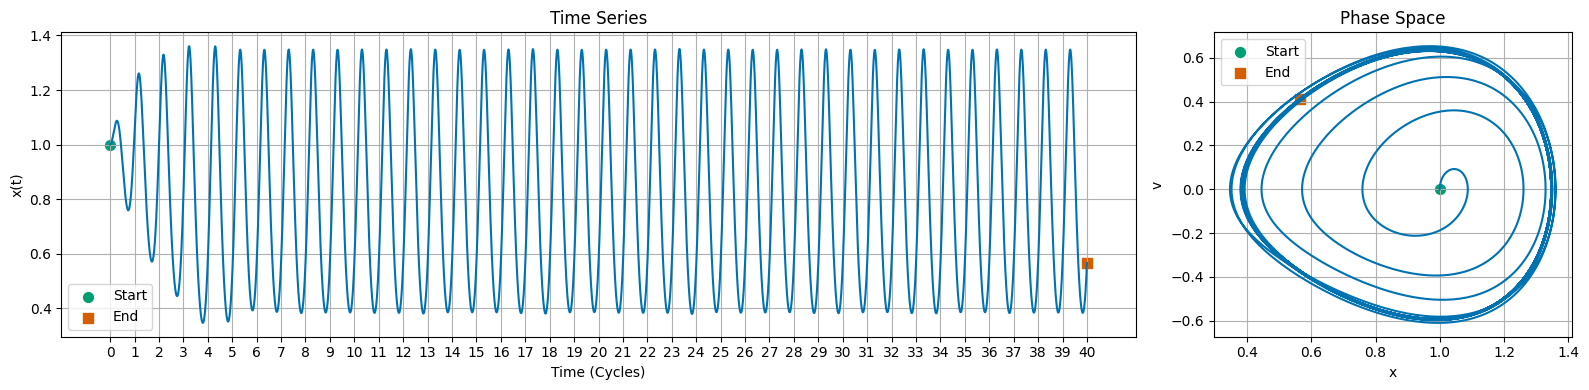

In [ ]:
plt.figure(figsize=(16, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])

T = 2 * np.pi / omega

# Time series plot
ax0 = plt.subplot(gs[0])
ax0.plot(t, x)
ax0.set_xticks(xticks, [f'{int(i/T)}' for i in xticks])
ax0.scatter(t[0],x[0], color='C1', marker='o', label='Start', s=50)
ax0.scatter(t[-1],x[-1], color='C2', marker='s', label='End', s=50)
ax0.set_title('Time Series')
ax0.set_xlabel('Time (Cycles)')
ax0.set_ylabel('x(t)')
ax0.grid(True)
ax0.legend()

# Phase space plot
ax1 = plt.subplot(gs[1])
ax1.plot(x, v, color='C0')
plt.scatter(x[0], v[0], color='C1', marker='o', label='Start', s=50)
plt.scatter(x[-1], v[-1], color='C2', marker='s', label='End', s=50)
ax1.set_title('Phase Space')
ax1.set_xlabel('x')
ax1.set_ylabel('v')
ax1.grid(True)
ax1.legend()

plt.tight_layout()

In [ ]:

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, x, label='x(t)')

#xticks should be integer values of T, but only ever Nth tick should be labeled
T = 2 * np.pi / omega
xticks = np.arange(0, tfinal + T, T)
plt.xticks(xticks, [f'{int(i/T)}' for i in xticks])
plt.scatter(t[0],x[0], color='green', marker='o', label='Start', s=50)
plt.scatter(t[-1],x[-1], color='r', marker='s', label='End', s=50)
plt.title('Time Series of the Duffing Oscillator')
plt.xlabel('Time (Cycles)')
plt.ylabel('Amplitude')

plt.grid()

# Plot phase space
plt.figure(figsize=(8, 8))
plt.plot(x, v)
plt.scatter(x[0], v[0], color='green', marker='o', label='Start', s=50)
plt.scatter(x[-1], v[-1], color='r', marker='s', label='End', s=50)
plt.title('Phase Space of the Duffing Oscillator')
plt.xlabel('x')
plt.ylabel('v')
plt.legend()
plt.grid()
plt.tight_layout()


In [35]:
def duffing(t, y, delta, alpha, beta, gamma, omega):
    x, v = y
    dxdt = v
    dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
    return [dxdt, dvdt]

def solve_duffing(delta, alpha, beta, gamma, omega, cycles=40, y0=[1.0, 0.0], num_points=100000):
    # Time span and initial conditions
    tfinal = 2 * np.pi * cycles / omega
    t_span = (0, tfinal)
    t_eval = np.linspace(t_span[0], t_span[1], num_points)

    # Solve the differential equations
    sol = solve_ivp(duffing, t_span, y0, args=(delta, alpha, beta, gamma, omega), t_eval=t_eval)
    x = sol.y[0]
    v = sol.y[1]
    t = sol.t

    return x, v, t

def plot_duffing(t, x, v, T):
    plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])

    # extract position and velocity data at intervals of T
    
    indices_at_T = np.arange(0, len(t), int(T / (t[1] - t[0])))
    xatT = x[indices_at_T]
    vatT = v[indices_at_T]
    t_atT = t[indices_at_T]
    
    ## Before plotting, remove the first half of all the data
    x = x[int(len(x)/2):]
    v = v[int(len(v)/2):]
    t = t[int(len(t)/2):]
    xatT = xatT[int(len(xatT)/2):]
    vatT = vatT[int(len(vatT)/2):]
    t_atT = t_atT[int(len(t_atT)/2):]

    ax0 = plt.subplot(gs[0])  
    ax0.plot(t, x)
    xticks = np.arange(0, t[-1] + T, T)
    ax0.set_xticks(xticks, [f'{int(i/T)}' for i in xticks])
    ax0.scatter(t[0], x[0], color='C1', marker='o', label='Start', s=50)
    ax0.scatter(t[-1], x[-1], color='C2', marker='s', label='End', s=50)
    ax0.scatter(t_atT, xatT, color='C3', marker='x', s=50)
    ax0.set_title('Time Series')
    ax0.set_xlabel('Time (Cycles)')
    ax0.set_ylabel('x(t)')
    ax0.grid(True)
    ax0.legend()

    # Phase space plot
    ax1 = plt.subplot(gs[1])
    ax1.plot(x, v, color='C0')
    ax1.scatter(x[0], v[0], color='C1', marker='o', label='Start', s=50)
    ax1.scatter(x[-1], v[-1], color='C2', marker='s', label='End', s=50)
    ax1.scatter(xatT, vatT, color='C3', marker='x', s=50)
    ax1.set_title('Phase Space')
    ax1.set_xlabel('x')
    ax1.set_ylabel('v')
    ax1.grid(True)
    ax1.legend()

    plt.tight_layout()

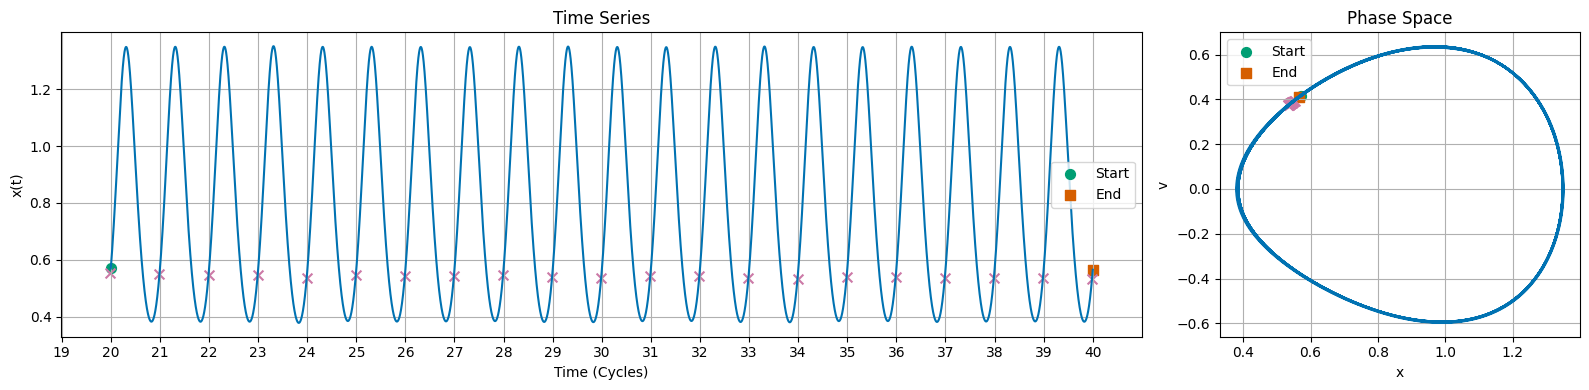

In [36]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.2
omega = 1.2
T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

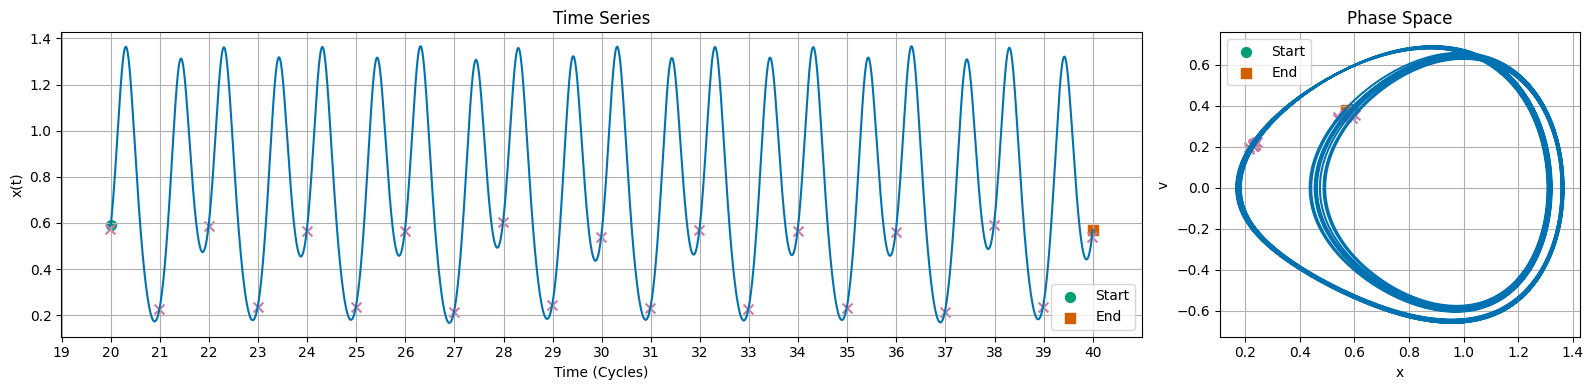

In [37]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.28
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

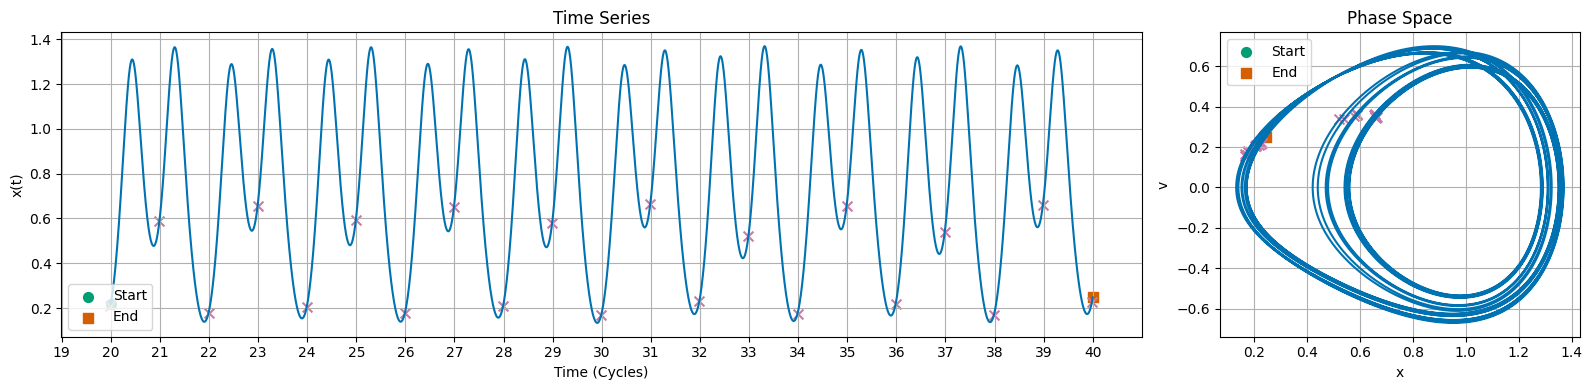

In [38]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.29
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

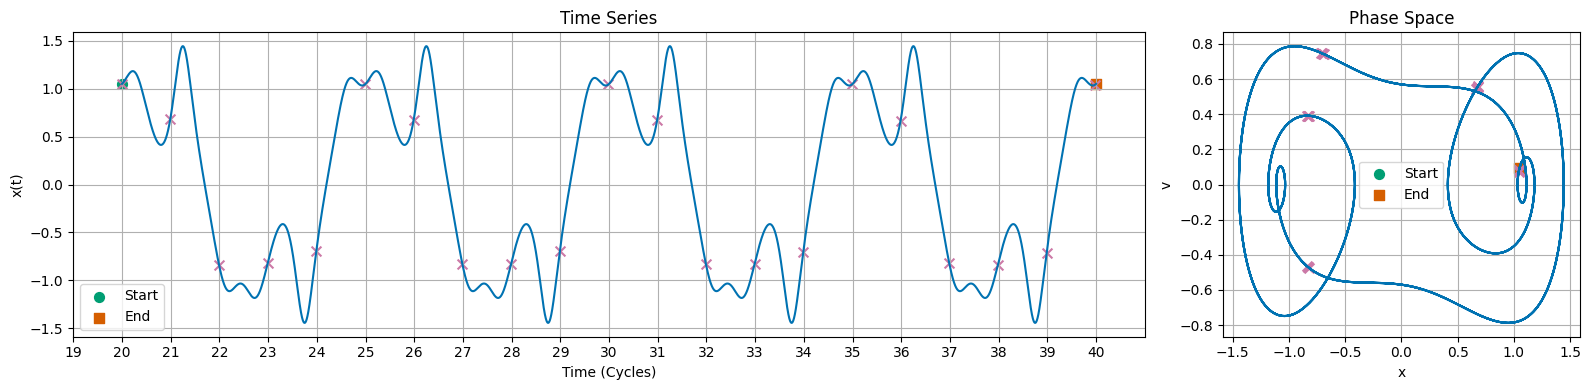

In [39]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.37
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

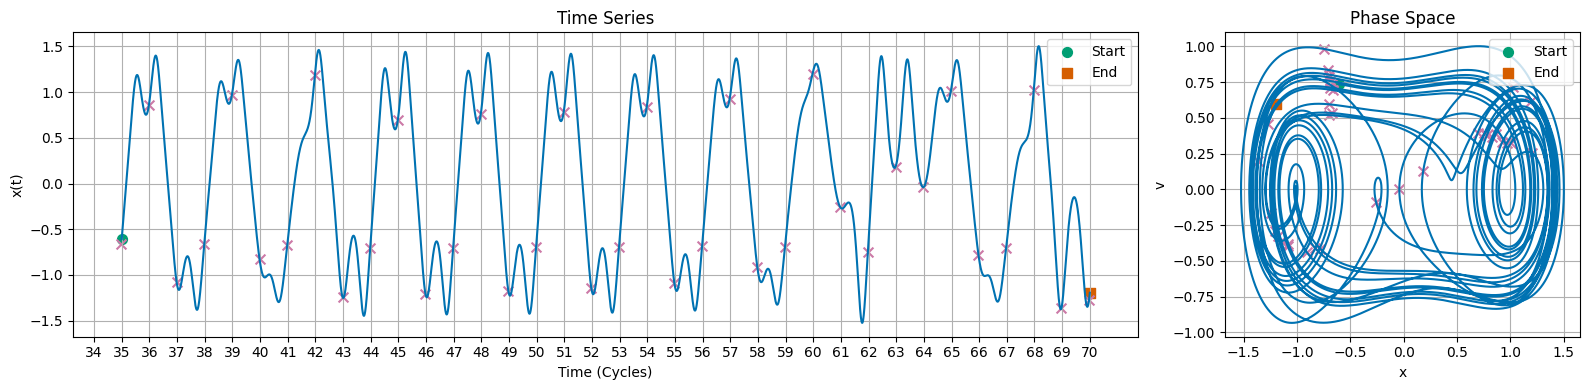

In [40]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.50
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega, cycles=70)
plot_duffing(t, x, v, T)

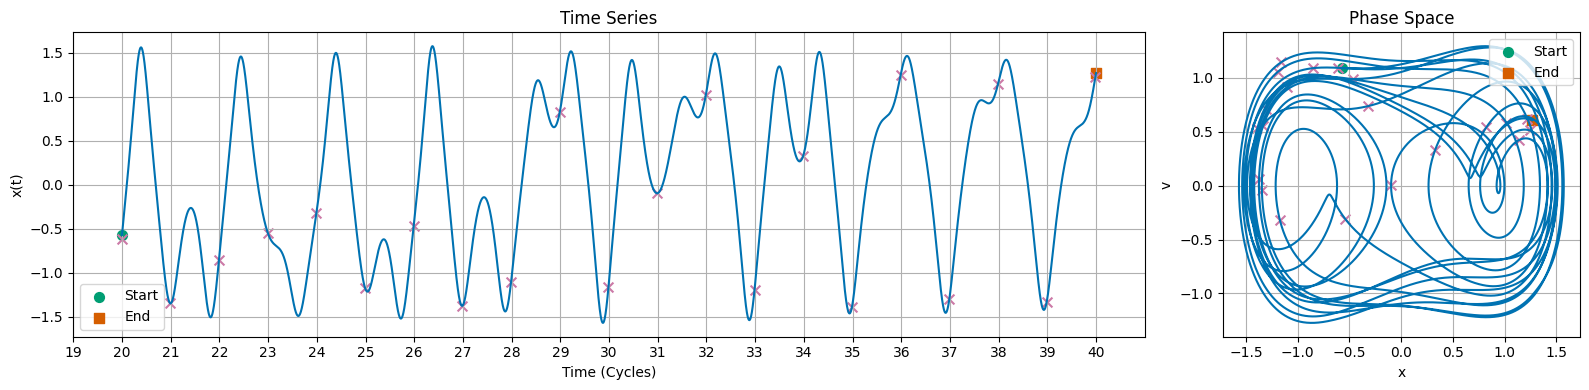

In [51]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.68
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

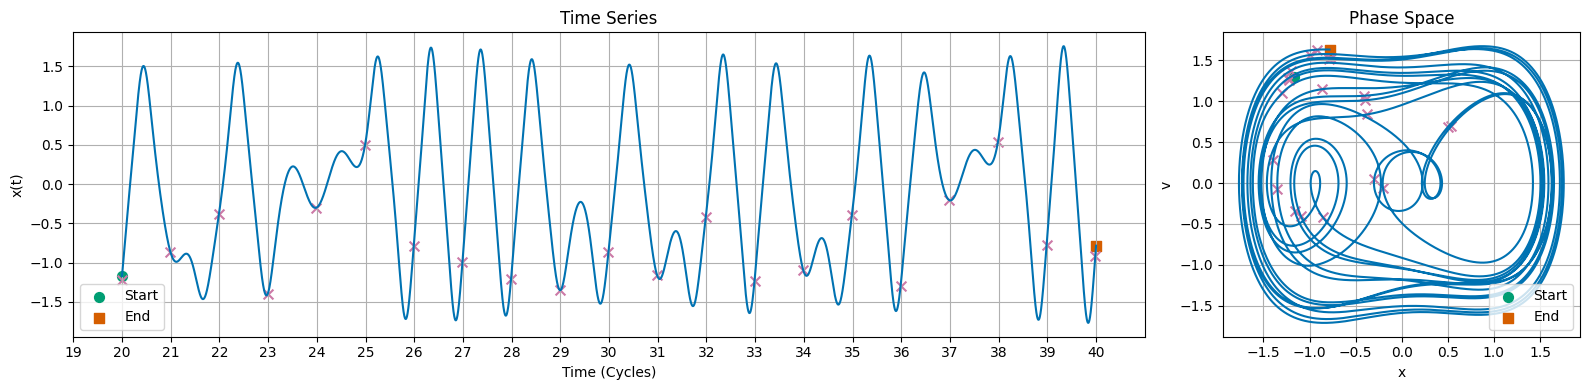

In [55]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.74
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

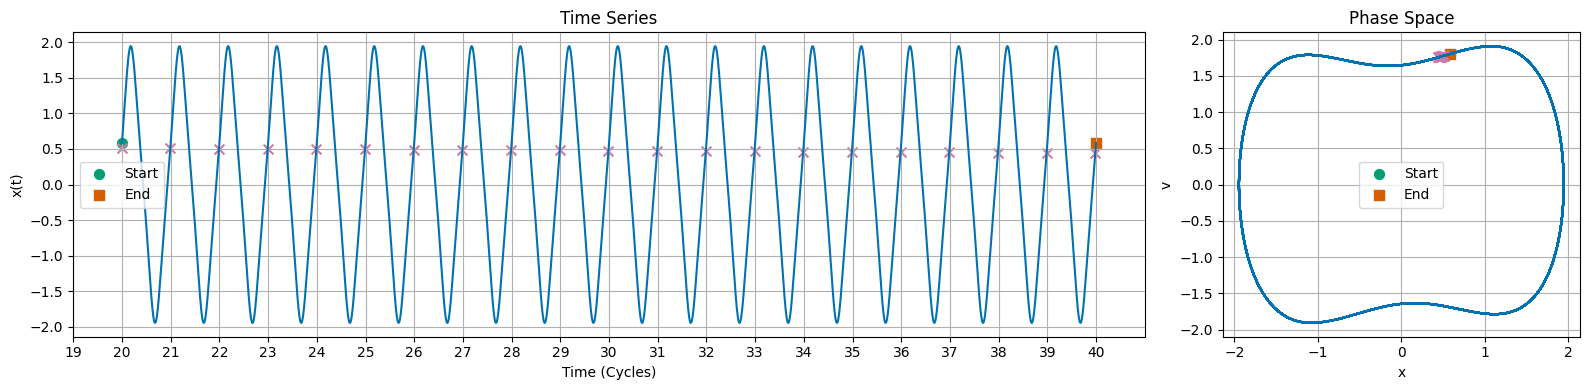

In [56]:
delta = 0.3
alpha = -1.0
beta = 1.0
gamma = 0.75
omega = 1.2

T = 2 * np.pi / omega

x, v, t = solve_duffing(delta, alpha, beta, gamma, omega)
plot_duffing(t, x, v, T)

## Lorenz Attractor

The Lorenz attractor is a system of ordinary differential equations that model atmospheric convection. It is given by:

$$\frac{dx}{dt} = \sigma (y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

Where $\sigma$, $\rho$, and $\beta$ are system parameters. The canonical values are $\sigma = 10$, $\rho = 28$, and $\beta = \frac{8}{3}$.
The Lorenz attractor is known for its chaotic solutions for certain parameter values and initial conditions.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.integrate import solve_ivp
plt.style.use('seaborn-v0_8-colorblind')

/var/folders/qv/mnq6bff11kbfx3jwqvl1w12m0000gn/T/ipykernel_86860/407742773.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


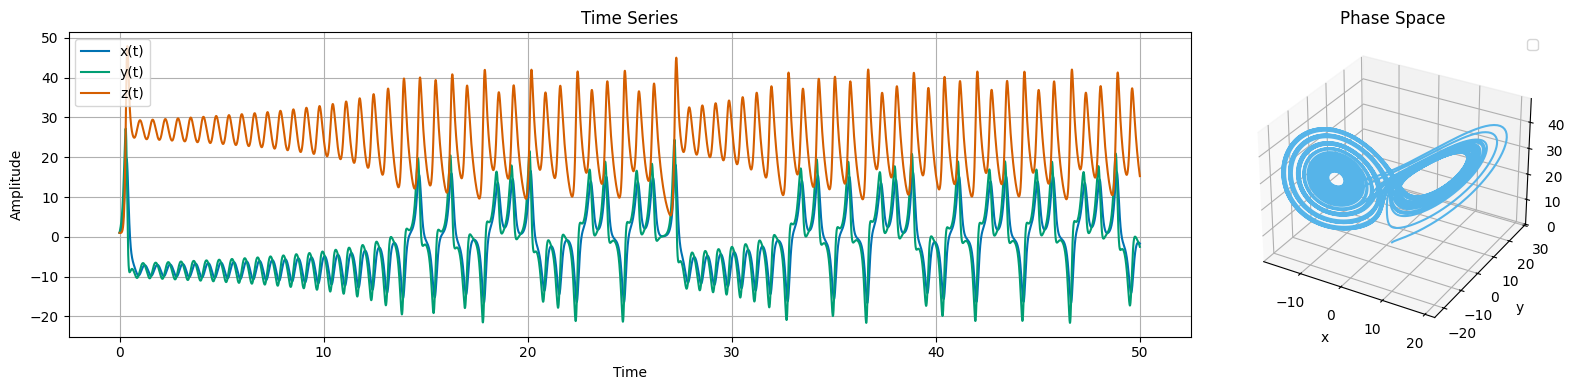

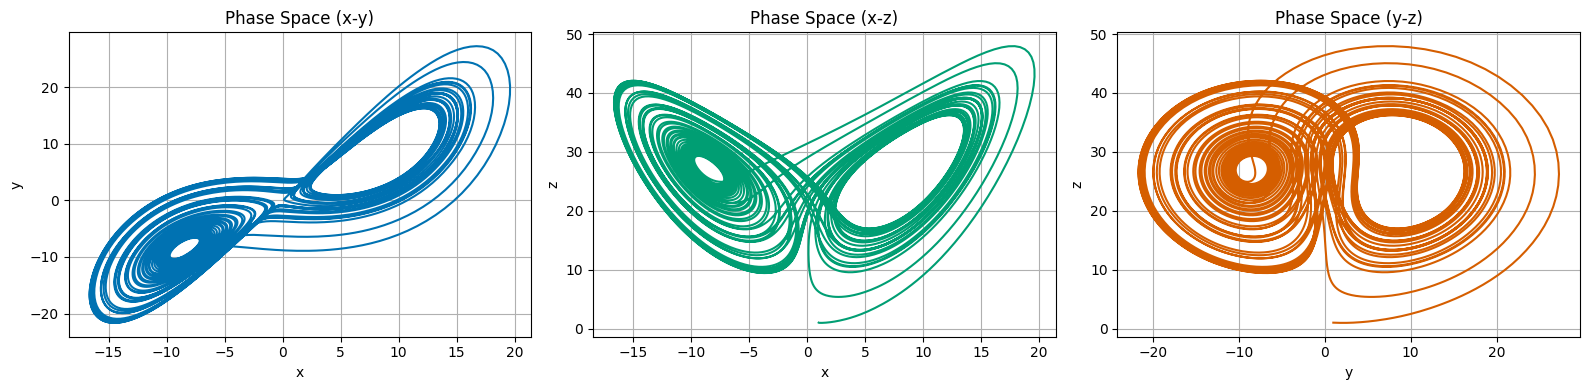

In [64]:
def lorenz(t, y, sigma, beta, rho):
    x, y, z = y
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Parameters for the Lorenz system
sigma = 10.0
beta = 8/3
rho = 28.0

# Time span and initial conditions
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
y0 = [1.0, 1.0, 1.0]

# Solve the differential equations

sol = solve_ivp(lorenz, t_span, y0, args=(sigma, beta, rho), t_eval=t_eval)
x = sol.y[0]
y = sol.y[1]
z = sol.y[2]

# Plotting

plt.figure(figsize=(16, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])
ax0 = plt.subplot(gs[0])
ax0.plot(sol.t, x, label='x(t)')
ax0.plot(sol.t, y, label='y(t)')
ax0.plot(sol.t, z, label='z(t)')
ax0.set_title('Time Series')
ax0.set_xlabel('Time')
ax0.set_ylabel('Amplitude')
ax0.legend()
plt.grid()

# 3D Phase Space Plot
ax1 = plt.subplot(gs[1], projection='3d')
ax1.plot(x, y, z, 'C5')
ax1.set_title('Phase Space')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
plt.legend()
plt.tight_layout()

# 2D Projections of Phase Space
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.plot(x, y, 'C6')
plt.title('Phase Space (x-y)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(x, z, 'C7')
plt.title('Phase Space (x-z)')
plt.xlabel('x')
plt.ylabel('z')
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(y, z, 'C8')
plt.title('Phase Space (y-z)')
plt.xlabel('y')
plt.ylabel('z')
plt.grid()
plt.tight_layout()

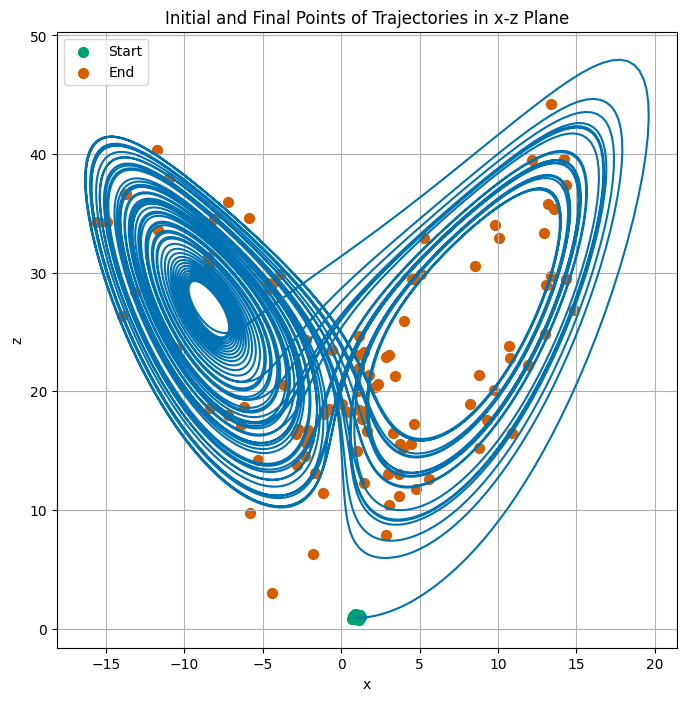

In [ ]:
# Bundle of trajectories

def lorenz(t, y, sigma, beta, rho):
    x, y, z = y
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

def solve_lorenz(y0, sigma=10.0, beta=8/3, rho=28.0, t_span=(0, 50), t_eval=np.linspace(0, 50, 10000)):
    sol = solve_ivp(lorenz, t_span, y0, args=(sigma, beta, rho), t_eval=t_eval)
    x = sol.y[0]
    y = sol.y[1]
    z = sol.y[2]
    return x, y, z, sol.t

# Example usage:
y0 = [1.0, 1.0, 1.0]
x, y, z, t = solve_lorenz(y0)

# pick 1000 random initial conditions near the original one
num_trajectories = 1000
initial_conditions = np.random.normal(loc=y0, scale=0.1, size=(num_trajectories, 3))
trajectories = []
for ic in initial_conditions:
    x, y, z, t = solve_lorenz(ic)
    # only store the initial and final points of the trajectory
    trajectories.append((x[0], y[0], z[0], x[-1], y[-1], z[-1]))
    
# Plot the initial and final points of all trajectories in the x-z plane
fig = plt.figure(figsize=(8, 8))
plt.plot(x, z, 'C0')
plt.title('Phase Space Projection (x-z)')
plt.scatter([traj[0] for traj in trajectories], [traj[2] for traj in trajectories], color='C1', s=50, label='Start')
plt.scatter([traj[3] for traj in trajectories], [traj[5] for traj in trajectories], color='C2', s=50, label='End')
plt.legend()
plt.title('Initial and Final Points of Trajectories in x-z Plane')
plt.xlabel('x')
plt.ylabel('z')
plt.grid()
plt.show()